# Bike Share Trips by Hour

This notebook presents the hourly trip analysis. Keep the reusable transformation in `src/analyze_trips.py`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA_PATH = PROJECT_ROOT / 'data' / 'bike_share_trips.csv'
trips = pd.read_csv(DATA_PATH, parse_dates=['started_at', 'ended_at'])

## Create an hourly summary

Derive the hour from each trip start time, then count trips by hour.

In [2]:
trips_by_hour = (
    trips.assign(hour=trips['started_at'].dt.hour)
    .groupby('hour', as_index=False)
    .size()
    .rename(columns={'size': 'trip_count'})
)
trips_by_hour

,hour,trip_count
0,0,56
1,1,56
2,2,56
3,3,56
4,4,56
5,5,56
6,6,56
7,7,168
8,8,252
9,9,168


## Visualize the pattern

Use a static chart now. You will add an interactive Plotly chart later.

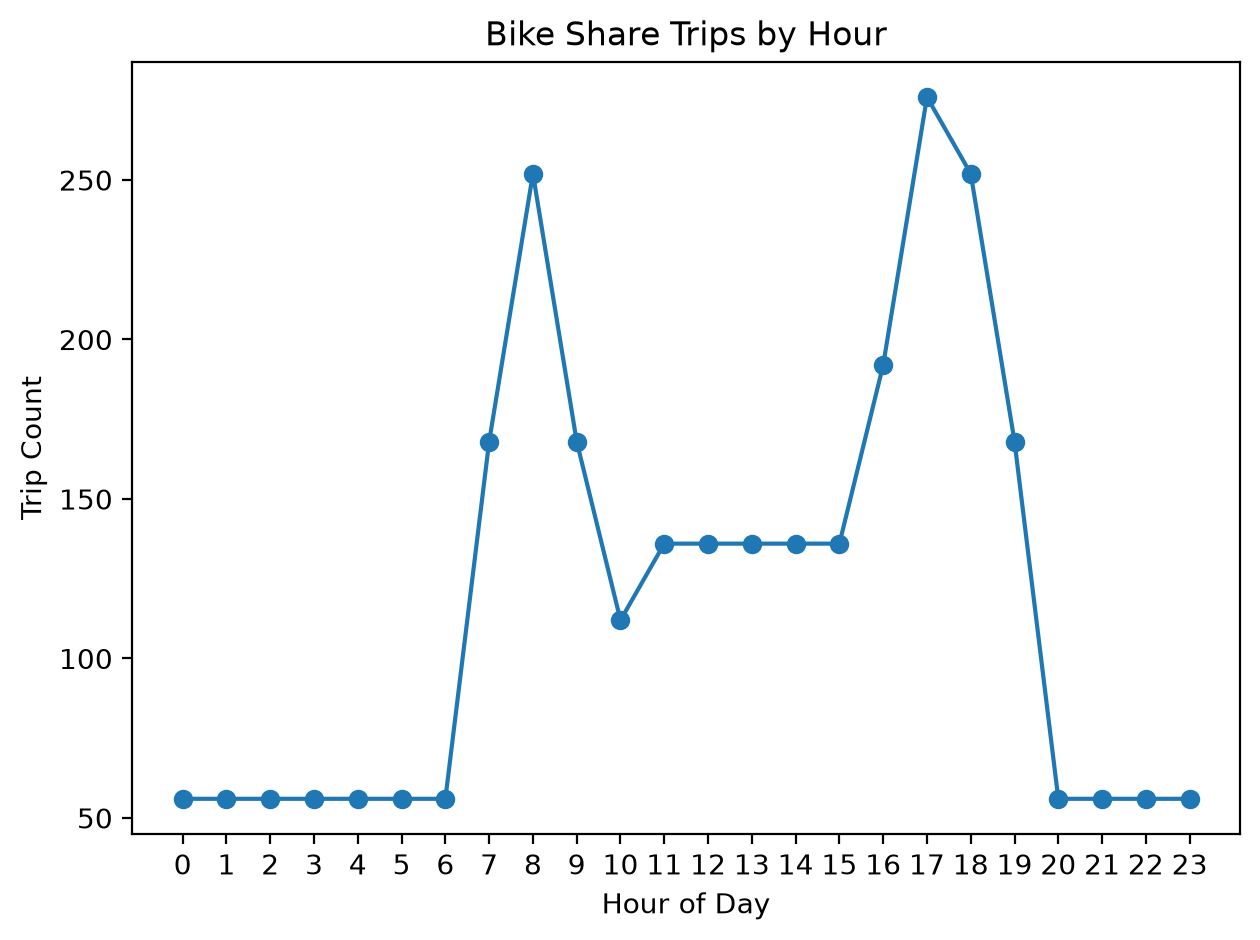

In [3]:
ax = trips_by_hour.plot(
    x='hour', y='trip_count', kind='line', marker='o', legend=False,
    title='Bike Share Trips by Hour'
)
ax.set(xlabel='Hour of Day', ylabel='Trip Count')
ax.set_xticks(range(24))
plt.tight_layout()
plt.show()

## Optional next step

After adding Plotly to the project, add a new cell below the static chart to create an interactive version.

In [4]:
import plotly.express as px

chart = px.line(
    trips_by_hour,
    x="hour",
    y="trip_count",
    markers=True,
    title="Bike Share Trips by Hour",
)
chart.show()